In [1]:
%pip install pandas numpy seaborn matplotlib openpyxl xlrd

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install lxml html5lib beautifulsoup4

^C
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
batter21=pd.read_html("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/마린스 21 타자 데이터.xls")[0]
batter22=pd.read_html("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/마린스 22 타자 데이터.xls")[0]
batter23=pd.read_html("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/마린스 23 타자 데이터.xls")[0]
batter24=pd.read_html("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/마린스 24 타자 데이터.xls")[0]
batter25=pd.read_html("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/마린스 25 타자 데이터.xls")[0]

In [ ]:
print(batter21.shape, batter22.shape, batter23.shape, batter24.shape, batter25.shape)

(64, 33) (34, 33) (24, 33) (30, 33) (27, 33)


In [ ]:
batter21.head()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
0,1.0,Jorge Alfaro,28.0,C,-0.5,92.0,311,295,22,72,...,0.293,72.0,101,8,5,0,0,0,27H/3,NaN
1,2.0,JesÃºs Aguilar,31.0,1B,1.3,131.0,510,449,49,117,...,0.338,107.0,206,11,3,0,7,4,*3H/D5,NaN
2,3.0,Jazz Chisholm Jr.*,23.0,2B,2.2,124.0,507,464,70,115,...,0.323,95.0,197,3,4,2,3,0,46/H,NaN
3,4.0,Miguel Rojas,32.0,SS,2.6,132.0,539,495,66,131,...,0.322,94.0,194,10,5,1,1,0,*6/H,NaN
4,5.0,Brian Anderson,28.0,3B,1.2,67.0,264,233,24,58,...,0.327,96.0,88,4,5,0,0,2,5/H6,NaN


In [ ]:
batter21.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
59,60.0,Andrew Bellatti,29.0,P,0.0,3.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,/1,NaN
60,61.0,Anthony Bass,33.0,P,0.0,67.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
61,NaN,Team Totals,NaN,NaN,10.3,162.0,5929,5348,623,1244,...,0.300,78.0,1990,95,65,30,30,25,NaN,NaN
62,NaN,Non-Pitcher Totals,NaN,NaN,11.3,NaN,5643,5091,616,1228,...,0.310,86.0,1969,93,64,11,30,25,NaN,NaN
63,NaN,Pitcher Totals,NaN,NaN,-1.0,NaN,286,257,7,16,...,0.096,-76.0,21,2,1,19,0,0,NaN,NaN


## 분석에 제외할 행 삭제

### - Team Totals, Non-Pitcher Totals, Pitcher Totals : 합계행은 선수 개별 분석에서는 제외함.

In [ ]:
remove_rows = ["Team Totals", "Non-Pitcher Totals", "Pitcher Totals"]

batter21 = batter21[~batter21["Player"].isin(remove_rows)].copy()
batter22 = batter22[~batter22["Player"].isin(remove_rows)].copy()
batter23 = batter23[~batter23["Player"].isin(remove_rows)].copy()
batter24 = batter24[~batter24["Player"].isin(remove_rows)].copy()
batter25 = batter25[~batter25["Player"].isin(remove_rows)].copy()

In [ ]:
for df in [batter21, batter22, batter23, batter24, batter25]:
    print(df["Player"].isin(remove_rows).sum())

0
0
0
0
0


In [ ]:
batter21.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
56,57.0,Sean Guenther*,25.0,P,0.0,13.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
57,58.0,Yimi GarcÃ­a,30.0,P,0.0,38.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
58,59.0,Dylan Floro*,30.0,P,0.0,65.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
59,60.0,Andrew Bellatti,29.0,P,0.0,3.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,/1,NaN
60,61.0,Anthony Bass,33.0,P,0.0,67.0,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN


In [ ]:
batter22.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
28,29.0,Zach Pop,25.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
29,30.0,Anthony Bass,34.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1/DH,NaN
30,31.0,Tanner Scott,27.0,P,0.0,3,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
31,32.0,Cole Sulser,32.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
32,33.0,Richard Bleier*,35.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN


In [ ]:
batter23.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
18,19.0,Dane Myers,27.0,CF,-0.4,22,70,67,9,18,...,0.271,59.0,24,1,0,0,1,0,8/7DH,NaN
19,20.0,Peyton Burdick,26.0,OF,0.0,14,37,33,4,6,...,0.276,55.0,11,0,1,0,0,0,9/8H7,NaN
20,21.0,Jacob Amaya,24.0,MI,0.0,4,9,9,1,2,...,0.226,6.0,2,0,0,0,0,0,/64,NaN
21,22.0,Bryan Hoeing,26.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN
22,23.0,Andrew Nardi*,24.0,P,0.0,1,0,0,0,0,...,NaN,NaN,0,0,0,0,0,0,1,NaN


In [ ]:
batter24.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
24,25.0,Jhonny Pereda,28.0,C,0.0,20,40,39,2,9,...,0.239,42,9,2,1,0,0,0,2/H13,NaN
25,26.0,Javier Sanoja,21.0,UT,0.0,15,36,35,3,8,...,0.235,38,10,2,0,0,0,0,/8H647D,NaN
26,27.0,Tristan Gray*,28.0,3B,-0.1,7,7,7,0,0,...,0.000,-131,0,0,0,0,0,0,/5H,NaN
27,28.0,JosÃ© Devers*,24.0,2B,0.1,3,4,4,1,1,...,0.224,30,1,0,0,0,0,0,/34H,NaN
28,29.0,Forrest Wall*,28.0,RF,0.0,3,3,3,1,1,...,0.379,85,1,0,0,0,0,0,/H9,NaN


In [ ]:
batter25.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards
21,22.0,Jonah Bride,29.0,CI,-0.4,12,45,40,3,4,...,0.161,-16,4,0,0,0,0,1,/D35H,NaN
22,23.0,VÃ­ctor Mesa Jr.*,23.0,OF,0.1,16,38,32,7,6,...,0.287,74,11,0,0,1,0,0,/798H,NaN
23,24.0,Jack Winkler,26.0,IF,-0.2,14,16,16,2,4,...,0.284,63,6,0,0,0,0,0,/4H365,NaN
24,25.0,Brian Navarreto,30.0,C,0.2,8,15,14,3,4,...,0.362,128,9,0,0,0,1,0,/2,NaN
25,26.0,Rob Brantly*,35.0,C,0.0,3,7,7,0,3,...,0.372,136,3,0,0,0,0,0,/2,NaN


In [ ]:
print(batter21.shape, batter22.shape, batter23.shape, batter24.shape, batter25.shape)

(61, 33) (33, 33) (23, 33) (29, 33) (26, 33)


### - 타자가 타석에 들어선 총 횟수(PA) = 0인 선수 행 삭제함.

In [ ]:
batter21 = batter21[batter21["PA"] != 0].copy()
batter22 = batter22[batter22["PA"] != 0].copy()
batter23 = batter23[batter23["PA"] != 0].copy()
batter24 = batter24[batter24["PA"] != 0].copy()
batter25 = batter25[batter25["PA"] != 0].copy()

In [ ]:
for df in [batter21, batter22, batter23, batter24, batter25]:
    print((df["PA"] == 0).sum())

0
0
0
0
0


In [ ]:
print(batter21.shape, batter22.shape, batter23.shape, batter24.shape, batter25.shape)

(51, 33) (25, 33) (21, 33) (29, 33) (26, 33)


## 데이터 합치기

In [ ]:
# 연도 컬럼 추가
batter21["year"] = 2021
batter22["year"] = 2022
batter23["year"] = 2023
batter24["year"] = 2024
batter25["year"] = 2025

In [ ]:
batter_all = pd.concat([batter21, batter22, batter23, batter24, batter25],
                     ignore_index=True)

In [ ]:
print(batter_all["year"].value_counts())

year
2021    51
2024    29
2025    26
2022    25
2023    21
Name: count, dtype: int64


In [ ]:
print(batter_all.shape)

(152, 34)


In [ ]:
batter_all.head()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards,year
0,1.0,Jorge Alfaro,28.0,C,-0.5,92.0,311,295,22,72,...,72.0,101,8,5,0,0,0,27H/3,NaN,2021
1,2.0,JesÃºs Aguilar,31.0,1B,1.3,131.0,510,449,49,117,...,107.0,206,11,3,0,7,4,*3H/D5,NaN,2021
2,3.0,Jazz Chisholm Jr.*,23.0,2B,2.2,124.0,507,464,70,115,...,95.0,197,3,4,2,3,0,46/H,NaN,2021
3,4.0,Miguel Rojas,32.0,SS,2.6,132.0,539,495,66,131,...,94.0,194,10,5,1,1,0,*6/H,NaN,2021
4,5.0,Brian Anderson,28.0,3B,1.2,67.0,264,233,24,58,...,96.0,88,4,5,0,0,2,5/H6,NaN,2021


In [ ]:
batter_all.tail()

,Rk,Player,Age,Pos,WAR,G,PA,AB,R,H,...,Rbat+,TB,GIDP,HBP,SH,SF,IBB,Pos.1,Awards,year
147,22.0,Jonah Bride,29.0,CI,-0.4,12.0,45,40,3,4,...,-16.0,4,0,0,0,0,1,/D35H,NaN,2025
148,23.0,VÃ­ctor Mesa Jr.*,23.0,OF,0.1,16.0,38,32,7,6,...,74.0,11,0,0,1,0,0,/798H,NaN,2025
149,24.0,Jack Winkler,26.0,IF,-0.2,14.0,16,16,2,4,...,63.0,6,0,0,0,0,0,/4H365,NaN,2025
150,25.0,Brian Navarreto,30.0,C,0.2,8.0,15,14,3,4,...,128.0,9,0,0,0,1,0,/2,NaN,2025
151,26.0,Rob Brantly*,35.0,C,0.0,3.0,7,7,0,3,...,136.0,3,0,0,0,0,0,/2,NaN,2025


# EDA

In [ ]:
batter= batter_all.copy()

In [ ]:
batter.shape

(152, 34)

### 결측치 확인

In [ ]:
batter.isnull().sum()

Rk          0
Player      0
Age         0
Pos         0
WAR         0
G           0
PA          0
AB          0
R           0
H           0
2B          0
3B          0
HR          0
RBI         0
SB          0
CS          0
BB          0
SO          0
BA          1
OBP         1
SLG         1
OPS         1
OPS+        1
rOBA        1
Rbat+       1
TB          0
GIDP        0
HBP         0
SH          0
SF          0
IBB         0
Pos.1       0
Awards    140
year        0
dtype: int64

### 분석에 제외할 칼럼 삭제

- **`Rk`  :** 단순 순번이라 분석 변수로 의미 없음.
- **`Pos.1`  :** 실제 수비 위치 상세 문자열인데 정리가 안 된 텍스트라 쓰기 어려움.
- **`Awards`  :** 대부분 결측치이고 일부 선수만 값 존재함.

In [ ]:
cols_to_drop = [
    'Rk', 'Pos.1', 'Awards'
]

In [ ]:
batter = batter.drop(columns=cols_to_drop)

In [ ]:
batter.shape

(152, 31)

In [ ]:
batter.head()

,Player,Age,Pos,WAR,G,PA,AB,R,H,2B,...,OPS+,rOBA,Rbat+,TB,GIDP,HBP,SH,SF,IBB,year
0,Jorge Alfaro,28.0,C,-0.5,92.0,311,295,22,72,15,...,69.0,0.293,72.0,101,8,5,0,0,0,2021
1,JesÃºs Aguilar,31.0,1B,1.3,131.0,510,449,49,117,23,...,111.0,0.338,107.0,206,11,3,0,7,4,2021
2,Jazz Chisholm Jr.*,23.0,2B,2.2,124.0,507,464,70,115,20,...,95.0,0.323,95.0,197,3,4,2,3,0,2021
3,Miguel Rojas,32.0,SS,2.6,132.0,539,495,66,131,30,...,93.0,0.322,94.0,194,10,5,1,1,0,2021
4,Brian Anderson,28.0,3B,1.2,67.0,264,233,24,58,9,...,94.0,0.327,96.0,88,4,5,0,0,2,2021


### PA: 타석 수

In [ ]:
batter["PA"].describe()

count    152.000000
mean     198.098684
std      177.732173
min        1.000000
25%       36.750000
50%      144.500000
75%      326.750000
max      626.000000
Name: PA, dtype: float64

<Axes: >

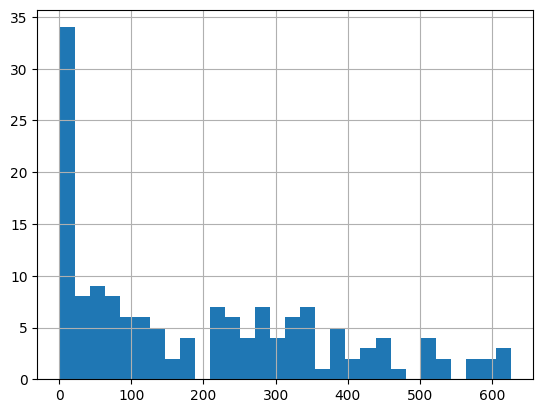

In [ ]:
# 소표본 선수 얼마나 많은지 확인
batter["PA"].hist(bins=30)

In [ ]:
# 소표본 선수 처리: 시즌 중 잠깐 뛴 선수는 PA가 너무 작아서 비율지표 해석이 불안정.
# PA < 50 기준으로 필터링한 버전 생성.
batter_pa50 = batter[batter["PA"] >= 50].copy()

In [ ]:
print("원본:", batter.shape)
print("PA 50 이상:", batter_pa50.shape)

원본: (152, 31)
PA 50 이상: (107, 31)


In [ ]:
# 제거된 선수 수 확인.
print("PA 50 미만 제거 수:", len(batter) - len(batter_pa50))

PA 50 미만 제거 수: 45


In [ ]:
# 연도별로 제거된 선수 수.
print(batter[batter["PA"] < 50].groupby("year").size())

year
2021    29
2022     4
2023     2
2024     5
2025     5
dtype: int64


In [ ]:
batter_pa50["PA"].describe()

count    107.000000
mean     274.635514
std      157.921188
min       51.000000
25%      131.000000
50%      271.000000
75%      381.500000
max      626.000000
Name: PA, dtype: float64

In [ ]:
batter_pa50[["PA","WAR","OPS","OPS+","HR","RBI"]].describe()

,PA,WAR,OPS,OPS+,HR,RBI
count,107.000000,107.000000,107.000000,107.000000,107.000000,107.000000
mean,274.635514,0.476636,0.668439,82.897196,7.130841,28.242991
std,157.921188,1.213803,0.113399,29.976071,6.774096,20.811753
min,51.000000,-2.100000,0.148000,-58.000000,0.000000,0.000000
25%,131.000000,-0.400000,0.603500,68.500000,2.500000,11.500000
50%,271.000000,0.200000,0.682000,88.000000,5.000000,26.000000
75%,381.500000,1.000000,0.731500,101.000000,9.500000,39.000000
max,626.000000,4.600000,0.912000,149.000000,36.000000,93.000000


array([[<Axes: title={'center': 'WAR'}>, <Axes: title={'center': 'OPS'}>],
       [<Axes: title={'center': 'HR'}>, <Axes: >]], dtype=object)

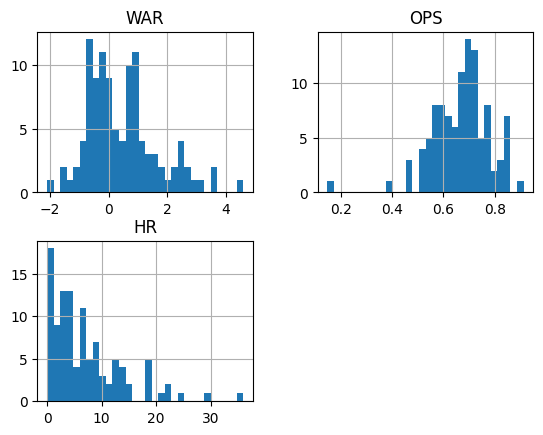

In [ ]:
batter_pa50[["WAR","OPS","HR"]].hist(bins=30)

### WAR: 대체선수 대비 승리 기여도

##### - 값이 클수록 팀 기여도가 높음.
##### - 타격, 주루, 수비 등을 종합적으로 반영한 대표 지표.

In [ ]:
batter_pa50["WAR"].describe()

count    107.000000
mean       0.476636
std        1.213803
min       -2.100000
25%       -0.400000
50%        0.200000
75%        1.000000
max        4.600000
Name: WAR, dtype: float64

<Axes: >

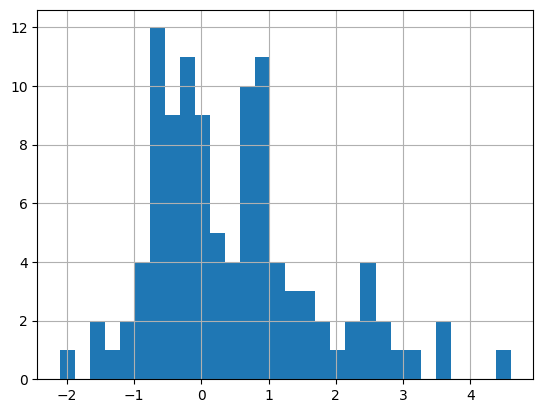

In [ ]:
batter_pa50["WAR"].hist(bins=30)

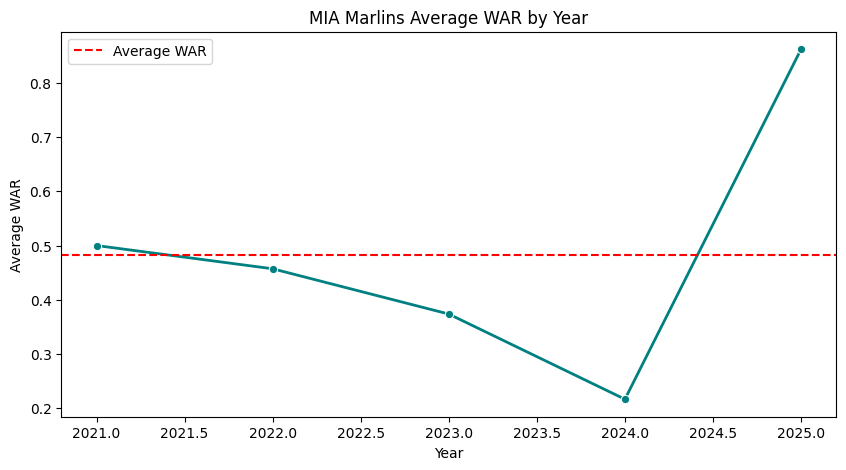

In [ ]:
# 연도별 평균 WAR 
year_war = batter_pa50.groupby("year")["WAR"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_war.index, y=year_war.values, marker='o', color='teal', linewidth=2)
plt.axhline(year_war.mean(), color='red', linestyle='--', label='Average WAR')
plt.title('MIA Marlins Average WAR by Year')
plt.xlabel('Year')
plt.ylabel('Average WAR')
plt.legend()
plt.show()

In [ ]:
# 연도별 WAR 상위 선수(2021~2025)
batter_pa50.sort_values(["year", "WAR"], ascending=[True, False]) \
         .groupby("year")[["Player","year","WAR","OPS","HR","PA"]] \
         .head(5)

,Player,year,WAR,OPS,HR,PA
6,Starling Marte,2021,2.9,0.856,7,275
3,Miguel Rojas,2021,2.6,0.713,9,539
2,Jazz Chisholm Jr.*,2021,2.2,0.728,18,507
7,Adam Duvall,2021,1.7,0.755,22,339
1,JesÃºs Aguilar,2021,1.3,0.788,22,510
54,Miguel Rojas,2022,2.5,0.605,6,507
53,Jazz Chisholm Jr.*,2022,2.4,0.860,14,241
60,Jon Berti,2022,2.4,0.662,4,404
61,Joey Wendle*,2022,2.4,0.658,3,371
63,Nick Fortes,2022,1.2,0.696,9,240


In [ ]:
# WAR 기준 상위 선수 10명
batter_pa50.sort_values("WAR", ascending=False)[["Player","year","WAR","OPS","HR"]].head(10)

,Player,year,WAR,OPS,HR
78,Luis ArrÃ¡ez*,2023,4.6,0.861,10
131,Kyle Stowers*,2025,3.6,0.912,25
129,Otto LÃ³pez,2025,3.5,0.672,15
128,Xavier Edwards#,2025,3.2,0.695,3
6,Starling Marte,2021,2.9,0.856,7
99,Otto LÃ³pez,2024,2.8,0.690,6
3,Miguel Rojas,2021,2.6,0.713,9
54,Miguel Rojas,2022,2.5,0.605,6
61,Joey Wendle*,2022,2.4,0.658,3
53,Jazz Chisholm Jr.*,2022,2.4,0.860,14


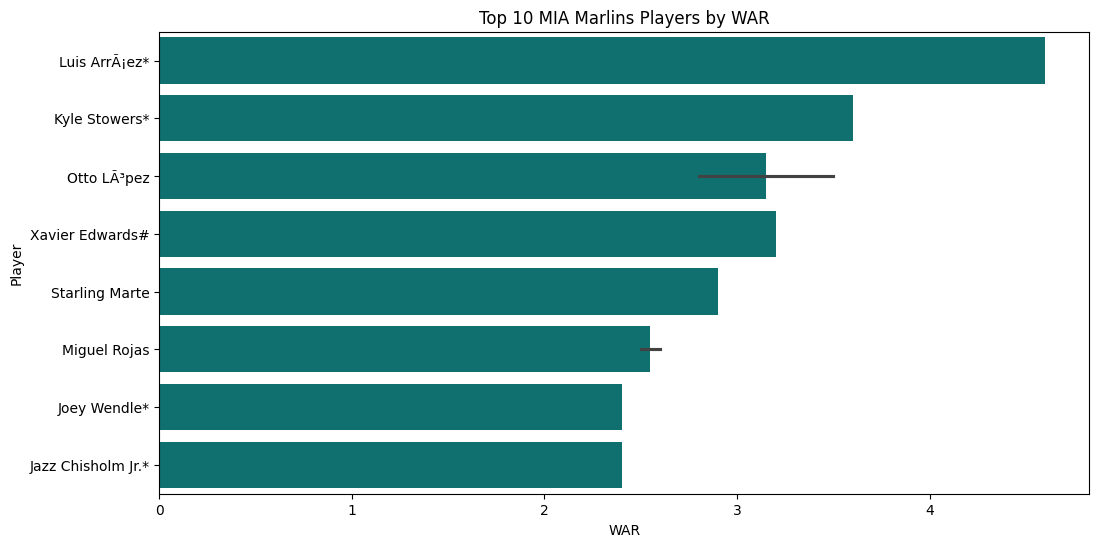

In [ ]:
# WAR 상위 10명 막대그래프
top_war = batter_pa50.sort_values("WAR", ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_war, x="WAR", y="Player", color="teal")
plt.title('Top 10 MIA Marlins Players by WAR')
plt.xlabel('WAR')
plt.ylabel('Player')
plt.show()

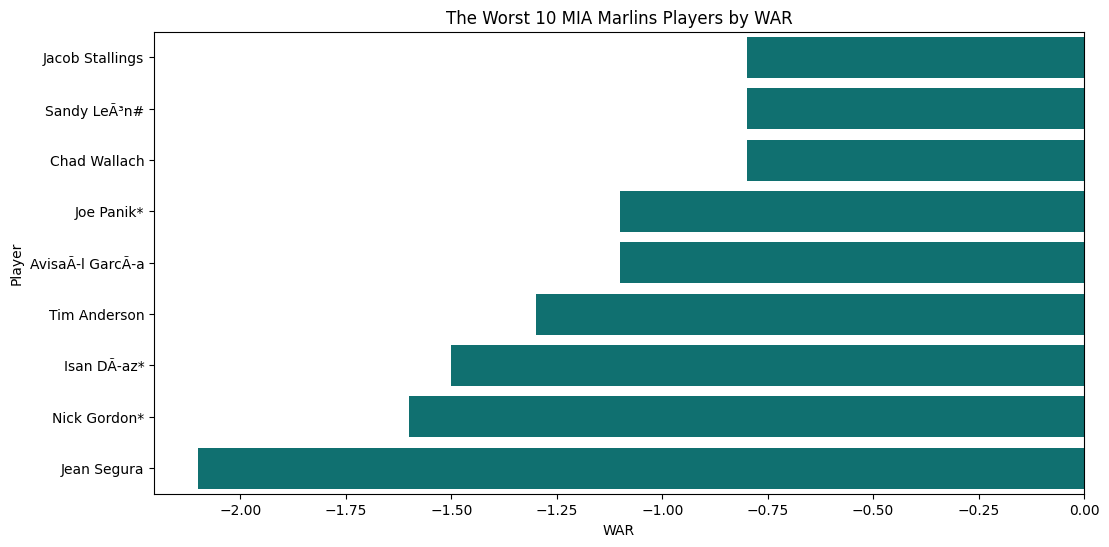

In [ ]:
# WAR 하위 10명 막대그래프
worst_war = batter_pa50.sort_values("WAR", ascending=False).tail(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=worst_war, x="WAR", y="Player", color="teal")
plt.title('The Worst 10 MIA Marlins Players by WAR')
plt.xlabel('WAR')
plt.ylabel('Player')
plt.show()

In [ ]:
# 선수별 5개년 누적 WAR
player_war_sum = batter_pa50.groupby("Player")["WAR"].sum().sort_values(ascending=False)
# 누적 WAR 상위 10명
player_war_sum.head(10)

Player
Jazz Chisholm Jr.*    7.0
Otto LÃ³pez           6.3
JesÃºs SÃ¡nchez*      5.5
Xavier Edwards#       5.4
Jon Berti             5.2
Miguel Rojas          5.1
Luis ArrÃ¡ez*         4.8
Kyle Stowers*         3.0
Starling Marte        2.9
Joey Wendle*          2.0
Name: WAR, dtype: float64

In [ ]:
# 누적 WAR 하위 10명
player_war_sum.tail(10)

Player
Ronny SimÃ³n#      -0.7
Chad Wallach       -0.8
Sandy LeÃ³n#       -0.8
Joe Panik*         -1.1
Tim Anderson       -1.3
Isan DÃ­az*        -1.5
Nick Gordon*       -1.6
Jacob Stallings    -1.6
AvisaÃ­l GarcÃ­a   -1.9
Jean Segura        -2.1
Name: WAR, dtype: float64

In [ ]:
player_war_sum.describe()

count    69.000000
mean      0.739130
std       1.980064
min      -2.100000
25%      -0.500000
50%       0.100000
75%       1.500000
max       7.000000
Name: WAR, dtype: float64

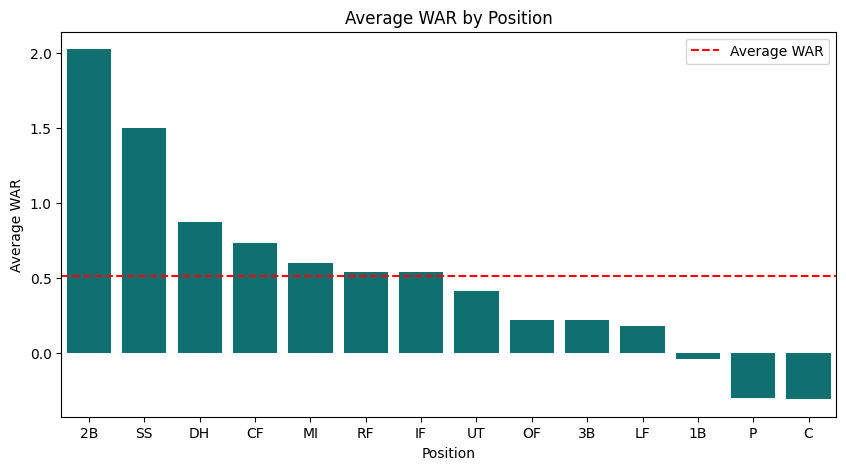

In [ ]:
# 포지션별 평균 WAR
pos_war = batter_pa50.groupby("Pos")["WAR"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=pos_war, x="Pos", y="WAR", color="teal")
plt.axhline(pos_war["WAR"].mean(), color='red', linestyle='--', label='Average WAR')
plt.title('Average WAR by Position')
plt.xlabel('Position')
plt.ylabel('Average WAR')
plt.legend()
plt.show()

### OPS: 출루율 + 장타율
#### 타자의 공격력을 간단히 종합한 대표 지표.
#### OPS+는 조정 OPS 값.

In [ ]:
batter_pa50["OPS"].describe()

count    107.000000
mean       0.668439
std        0.113399
min        0.148000
25%        0.603500
50%        0.682000
75%        0.731500
max        0.912000
Name: OPS, dtype: float64

In [ ]:
batter_pa50["OPS+"].describe()

count    107.000000
mean      82.897196
std       29.976071
min      -58.000000
25%       68.500000
50%       88.000000
75%      101.000000
max      149.000000
Name: OPS+, dtype: float64

<Axes: >

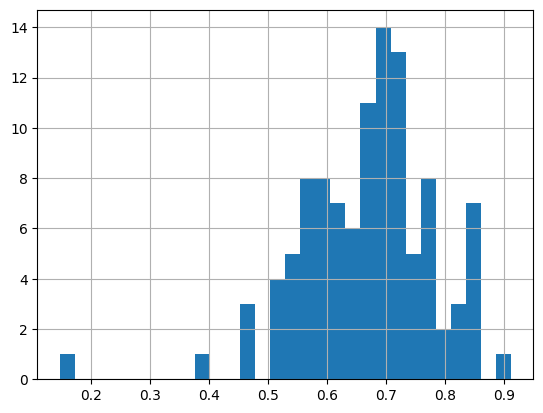

In [ ]:
batter_pa50["OPS"].hist(bins=30)

<Axes: >

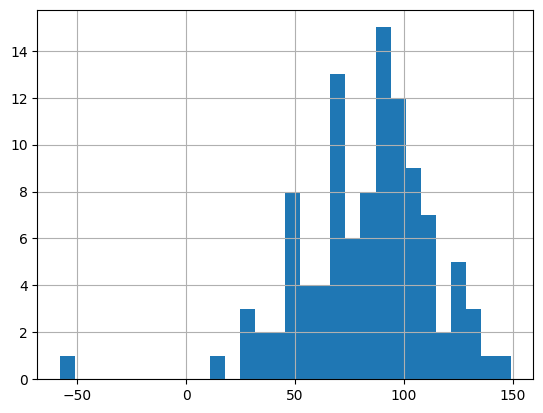

In [ ]:
batter_pa50["OPS+"].hist(bins=30)

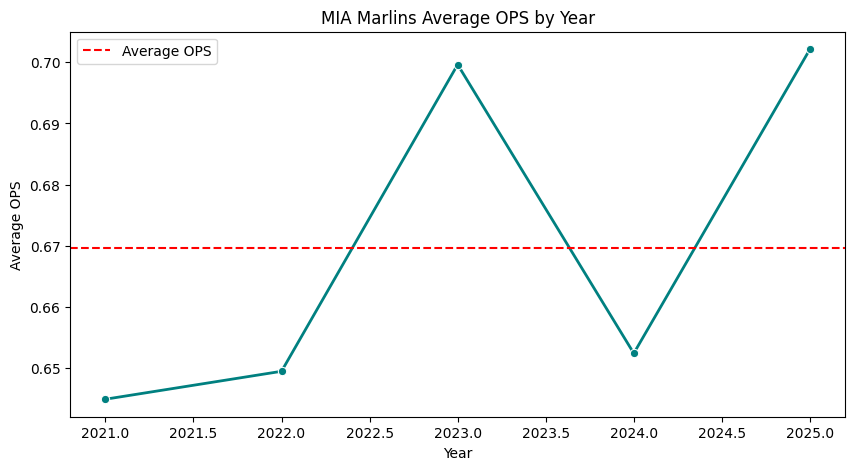

In [ ]:
# 연도별 평균 OPS
year_ops = batter_pa50.groupby("year")["OPS"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=year_ops.index, y=year_ops.values, marker='o', color='teal', linewidth=2)
plt.axhline(year_ops.mean(), color='red', linestyle='--', label='Average OPS')
plt.title('MIA Marlins Average OPS by Year')
plt.xlabel('Year')
plt.ylabel('Average OPS')
plt.legend()
plt.show()

In [ ]:
# 포지션별 평균 OPS
batter_pa50.groupby("Pos")["OPS"].mean().sort_values(ascending=False)

Pos
DH    0.774000
2B    0.742375
RF    0.711100
LF    0.701667
1B    0.699909
OF    0.692400
CF    0.680909
3B    0.680182
UT    0.663429
SS    0.637833
MI    0.622000
IF    0.620500
C     0.566692
P     0.148000
Name: OPS, dtype: float64

In [ ]:
# 포지션별 평균 OPS+
batter_pa50.groupby("Pos")["OPS+"].mean().sort_values(ascending=False)

Pos
DH    111.000000
2B    103.250000
RF     92.800000
LF     91.666667
OF     89.800000
1B     89.363636
3B     86.454545
CF     85.272727
UT     84.000000
SS     76.000000
MI     74.000000
IF     71.375000
C      55.461538
P     -58.000000
Name: OPS+, dtype: float64

In [ ]:
# 선수별 5개년 평균 OPS
player_ops_avg = batter_pa50.groupby("Player")["OPS"].mean().sort_values(ascending=False)
# 5개년 평균 OPS 상위 10명
player_ops_avg.head(10)

Player
Starling Marte          0.856000
Jakob Marsee*           0.842000
Jonah Bride             0.818000
Jake Burger             0.810000
Luis ArrÃ¡ez*           0.790000
Heriberto HernÃ¡ndez    0.784000
Jorge Soler             0.774000
Garrett Cooper          0.773333
Jazz Chisholm Jr.*      0.769750
Josh Bell#              0.758500
Name: OPS, dtype: float64

In [ ]:
# 5개년 평균 OPS 하위 10명
player_ops_avg.tail(10)

Player
Jerar EncarnaciÃ³n       0.548
Alex Jackson             0.538
Cristian Pache           0.518
Chad Wallach             0.509
Sandy LeÃ³n#             0.505
Christian Bethancourt    0.466
Tim Anderson             0.463
Joe Panik*               0.462
Ali SÃ¡nchez             0.402
Sandy Alcantara          0.148
Name: OPS, dtype: float64

In [ ]:
# OPS 상위 선수
batter_pa50.sort_values("OPS", ascending=False)[["Player","year","OPS","WAR","PA","HR"]].head(10)

,Player,year,OPS,WAR,PA,HR
131,Kyle Stowers*,2025,0.912,3.6,457,25
78,Luis ArrÃ¡ez*,2023,0.861,4.6,617,10
53,Jazz Chisholm Jr.*,2022,0.860,2.4,241,14
90,Jake Burger,2023,0.860,1.0,217,9
6,Starling Marte,2021,0.856,2.9,275,7
84,Jorge Soler,2023,0.853,1.5,580,36
12,Garrett Cooper,2021,0.845,1.0,250,9
137,Jakob Marsee*,2025,0.842,1.9,234,5
100,Xavier Edwards#,2024,0.820,2.1,303,1
89,Josh Bell#,2023,0.818,0.2,224,11


In [ ]:
# OPS 하위 선수
batter_pa50.sort_values("OPS", ascending=False)[["Player","year","OPS","WAR","PA","HR"]].tail(10)

,Player,year,OPS,WAR,PA,HR
18,Alex Jackson,2021,0.538,-0.3,123,3
118,Cristian Pache,2024,0.518,-0.3,64,1
65,Lewin DÃ­az*,2022,0.512,-0.5,174,5
20,Chad Wallach,2021,0.509,-0.8,66,0
14,Sandy LeÃ³n#,2021,0.505,-0.8,220,4
117,Christian Bethancourt,2024,0.466,-0.5,88,2
108,Tim Anderson,2024,0.463,-1.3,241,0
16,Joe Panik*,2021,0.462,-1.1,134,1
115,Ali SÃ¡nchez,2024,0.402,-0.6,96,0
28,Sandy Alcantara,2021,0.148,-0.3,64,0


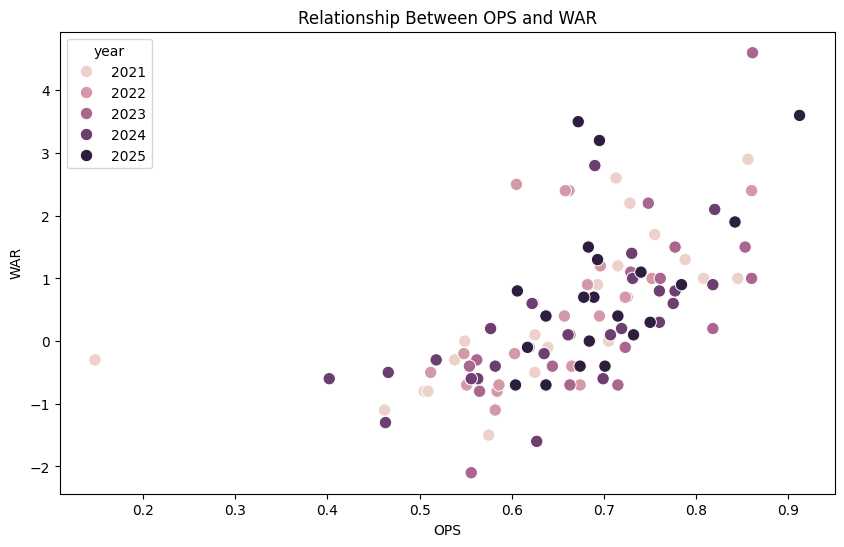

In [ ]:
# WAR과 OPS의 관계
plt.figure(figsize=(10, 6))
sns.scatterplot(data=batter_pa50, x="OPS", y="WAR", hue="year", s=80)
plt.title('Relationship Between OPS and WAR')
plt.xlabel('OPS')
plt.ylabel('WAR')
plt.show()

In [ ]:
# 해석: OPS가 높을수록 WAR도 높음. 강한 양의 상관관계.

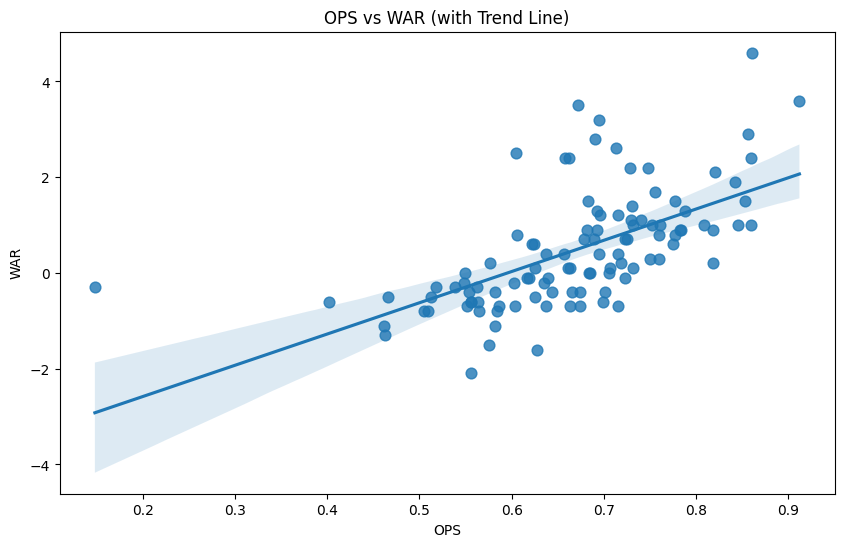

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(data=batter_pa50, x="OPS", y="WAR", scatter_kws={"s":60})

plt.title("OPS vs WAR (with Trend Line)")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.show()

In [ ]:
# OPS는 높은데 WAR는 낮은 선수(저평가되는 느낌이 있는 선수)
# 즉, 공격력은 좋지만 전체 기여도는 낮은 선수
batter_pa50[
    (batter_pa50["OPS"] >= 0.800) & 
    (batter_pa50["WAR"] <= 1)
][["Player","year","OPS","WAR","PA","Pos"]]

,Player,year,OPS,WAR,PA,Pos
11,JesÃºs SÃ¡nchez*,2021,0.808,1.0,251,OF
12,Garrett Cooper,2021,0.845,1.0,250,RF
89,Josh Bell#,2023,0.818,0.2,224,1B
90,Jake Burger,2023,0.860,1.0,217,3B
107,Jonah Bride,2024,0.818,0.9,272,1B


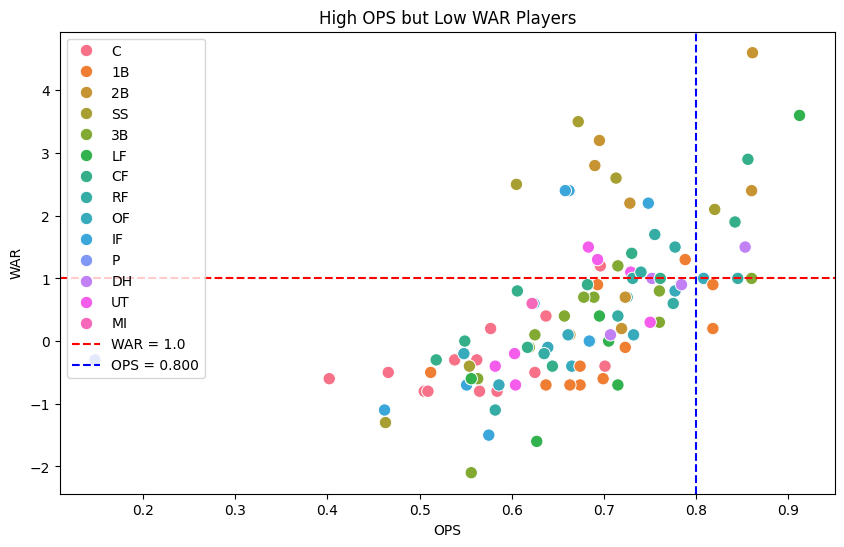

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=batter_pa50, x="OPS", y="WAR", hue="Pos", s=80)

plt.axhline(1.0, color="red", linestyle="--", label="WAR = 1.0")
plt.axvline(0.800, color="blue", linestyle="--", label="OPS = 0.800")

plt.title("High OPS but Low WAR Players")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.legend()
plt.show()

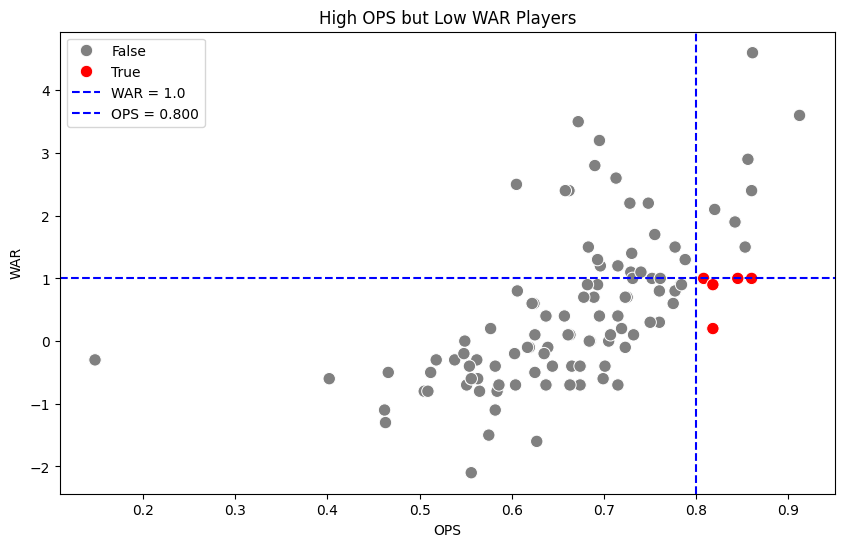

In [ ]:
# 점 색깔로 구분

batter_pa50["undervalued_like"] = (
    (batter_pa50["OPS"] >= 0.800) &
    (batter_pa50["WAR"] <= 1.0)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=batter_pa50,
    x="OPS",
    y="WAR",
    hue="undervalued_like",
    palette={True: "red", False: "gray"},
    s=80
)

plt.axhline(1.0, color="blue", linestyle="--", label="WAR = 1.0")
plt.axvline(0.800, color="blue", linestyle="--", label="OPS = 0.800")

plt.title("High OPS but Low WAR Players")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.legend()
plt.show()

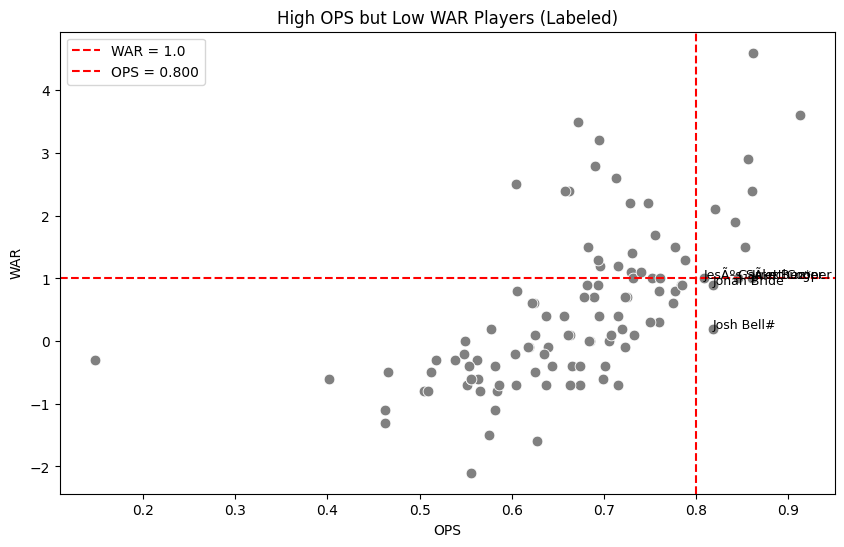

In [ ]:
# 선수 이름 표시
plt.figure(figsize=(10, 6))
sns.scatterplot(data=batter_pa50, x="OPS", y="WAR", color="gray", s=60)

subset = batter_pa50[
    (batter_pa50["OPS"] >= 0.800) &
    (batter_pa50["WAR"] <= 1.0)
]

for _, row in subset.iterrows():
    plt.text(row["OPS"], row["WAR"], row["Player"], fontsize=9)

plt.axhline(1.0, color="red", linestyle="--", label="WAR = 1.0")
plt.axvline(0.800, color="red", linestyle="--", label="OPS = 0.800")

plt.title("High OPS but Low WAR Players (Labeled)")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.legend()
plt.show()

In [ ]:
# WAR는 높은데 OPS는 낮은 선수(고평가)
# 공격 지표는 평범하지만 수비/주루/포지션 가치 때문에 기여도가 높은 선수일 가능성

high_war_low_ops = batter_pa50[
    (batter_pa50["WAR"] >= 1.5) &
    (batter_pa50["OPS"] < 0.750)
][["Player", "year", "WAR", "OPS", "PA", "Pos"]].sort_values("WAR", ascending=False)

high_war_low_ops

,Player,year,WAR,OPS,PA,Pos
129,Otto LÃ³pez,2025,3.5,0.672,594,SS
128,Xavier Edwards#,2025,3.2,0.695,619,2B
99,Otto LÃ³pez,2024,2.8,0.690,434,2B
3,Miguel Rojas,2021,2.6,0.713,539,SS
54,Miguel Rojas,2022,2.5,0.605,507,SS
60,Jon Berti,2022,2.4,0.662,404,IF
61,Joey Wendle*,2022,2.4,0.658,371,IF
2,Jazz Chisholm Jr.*,2021,2.2,0.728,507,2B
85,Jon Berti,2023,2.2,0.748,424,IF
136,Javier Sanoja,2025,1.5,0.683,342,UT


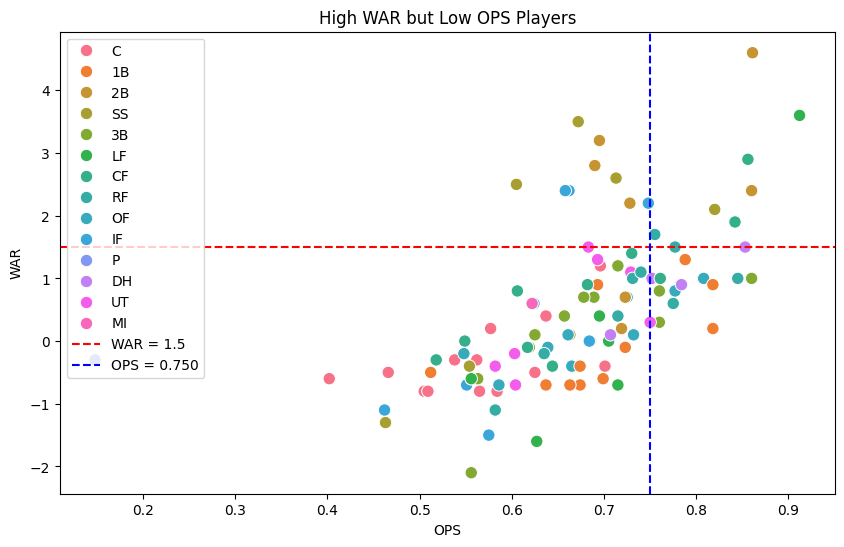

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=batter_pa50, x="OPS", y="WAR", hue="Pos", s=80)

plt.axhline(1.5, color="red", linestyle="--", label="WAR = 1.5")
plt.axvline(0.750, color="blue", linestyle="--", label="OPS = 0.750")

plt.title("High WAR but Low OPS Players")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.legend()
plt.show()

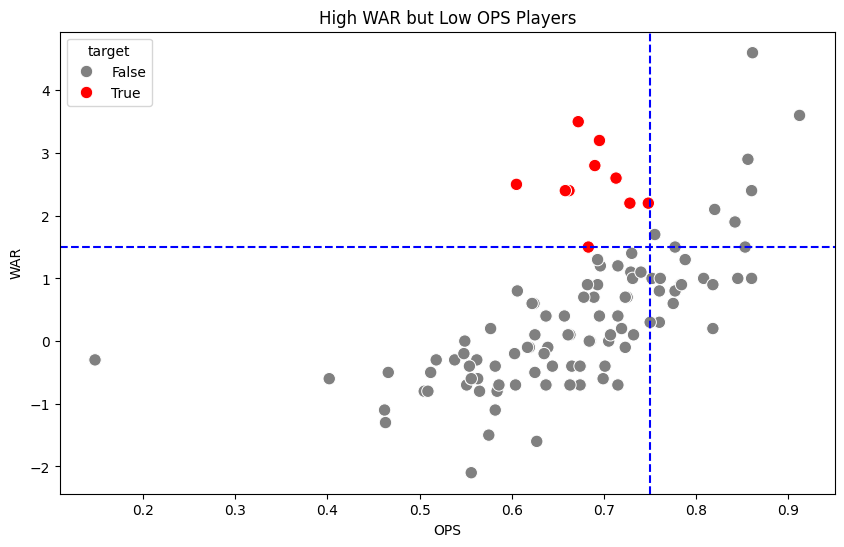

In [ ]:
# 점 색깔로 구분
batter_pa50["target"] = (
    (batter_pa50["WAR"] >= 1.5) & 
    (batter_pa50["OPS"] < 0.750)
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=batter_pa50,
    x="OPS",
    y="WAR",
    hue="target",
    palette={True: "red", False: "gray"},
    s=80
)

plt.axhline(1.5, color="blue", linestyle="--")
plt.axvline(0.750, color="blue", linestyle="--")

plt.title("High WAR but Low OPS Players")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.show()

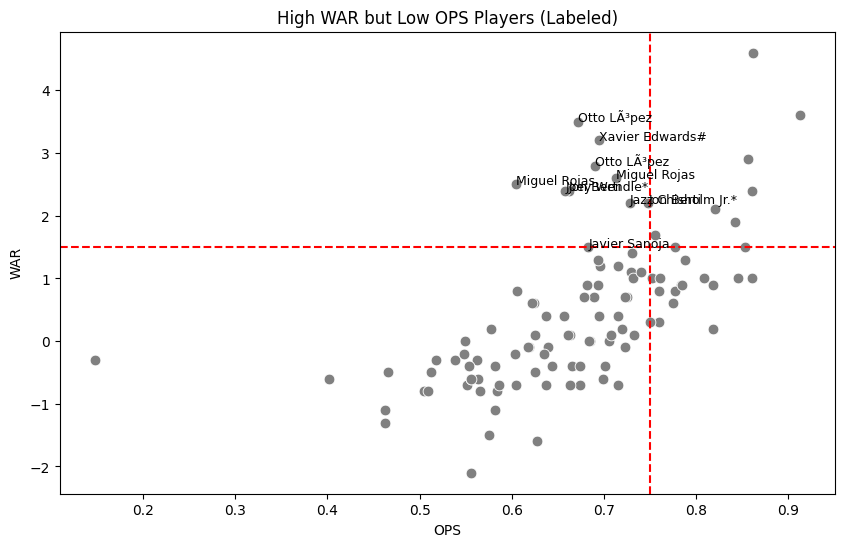

In [ ]:
# 선수 이름 표시
plt.figure(figsize=(10, 6))
sns.scatterplot(data=batter_pa50, x="OPS", y="WAR", color="gray", s=60)

# 조건 만족 선수만 라벨
subset = batter_pa50[
    (batter_pa50["WAR"] >= 1.5) & 
    (batter_pa50["OPS"] < 0.750)
]

for _, row in subset.iterrows():
    plt.text(row["OPS"], row["WAR"], row["Player"], fontsize=9)

plt.axhline(1.5, color="red", linestyle="--")
plt.axvline(0.750, color="red", linestyle="--")

plt.title("High WAR but Low OPS Players (Labeled)")
plt.xlabel("OPS")
plt.ylabel("WAR")
plt.show()

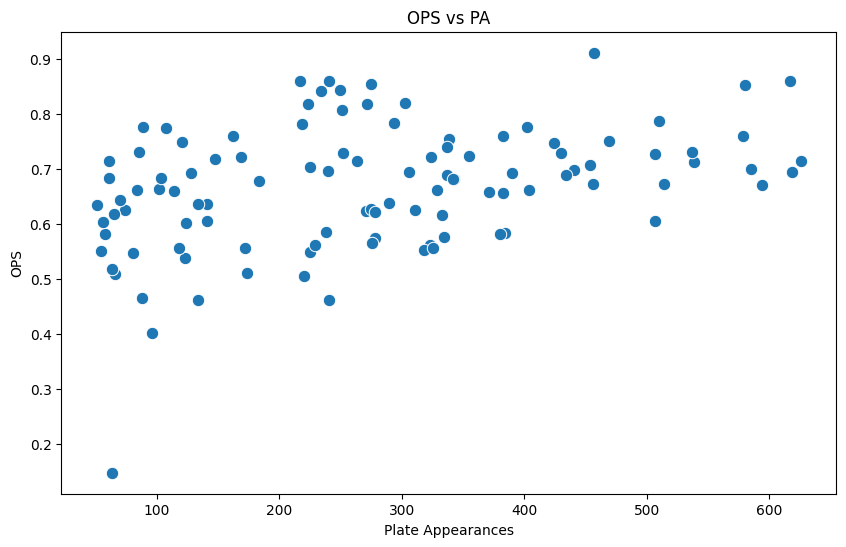

In [ ]:
# OPS 대비 효율(PA 고려)
# OPS 높아도 PA 적으면 의미 떨어짐. 많이 뛰면서 OPS 높은 선수가 좋은 선수.
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="PA", y="OPS", s=80)

plt.title("OPS vs PA")
plt.xlabel("Plate Appearances")
plt.ylabel("OPS")
plt.show()

In [ ]:
# OPS 상위 25%이면서 PA 하위 25%인 선수(효율 낮은 선수)
ops_q75 = batter_pa50["OPS"].quantile(0.75)
pa_q25 = batter_pa50["PA"].quantile(0.25)

high_ops_low_pa = batter_pa50[
    (batter_pa50["OPS"] >= ops_q75) &
    (batter_pa50["PA"] <= pa_q25)
][["Player", "year", "OPS", "PA", "WAR", "Pos"]].sort_values(
    "OPS", ascending=False
)

high_ops_low_pa.head(10)

,Player,year,OPS,PA,WAR,Pos
116,Griffin Conine*,2024,0.777,89,0.8,OF
114,Dane Myers,2024,0.775,108,0.6,RF
142,Troy Johnston*,2025,0.750,121,0.3,UT
143,Griffin Conine*,2025,0.732,86,0.1,OF


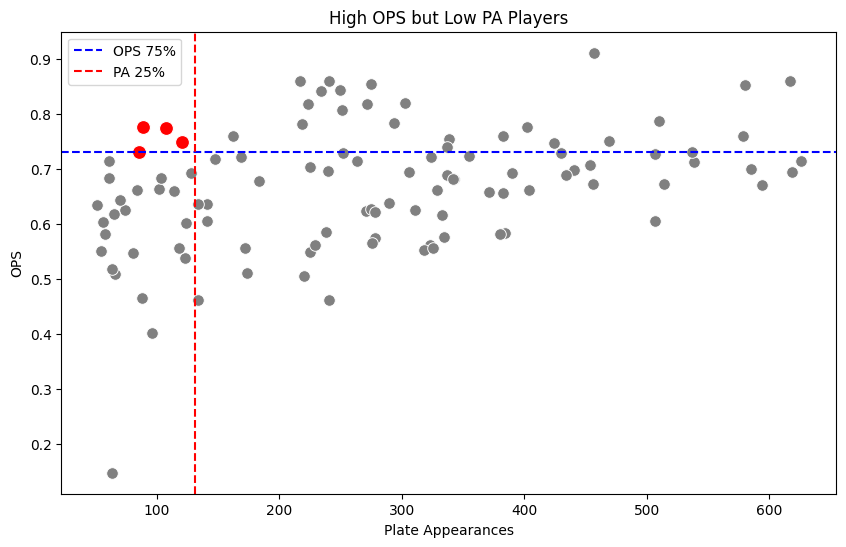

In [ ]:
# 시각화
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="PA", y="OPS", color="gray", s=70)

subset = batter_pa50[
    (batter_pa50["OPS"] >= ops_q75) &
    (batter_pa50["PA"] <= pa_q25)
]

sns.scatterplot(data=subset, x="PA", y="OPS", color="red", s=100)

plt.axhline(ops_q75, color="blue", linestyle="--", label="OPS 75%")
plt.axvline(pa_q25, color="red", linestyle="--", label="PA 25%")

plt.title("High OPS but Low PA Players")
plt.xlabel("Plate Appearances")
plt.ylabel("OPS")
plt.legend()
plt.show()

### Age: 나이

In [ ]:
batter_pa50["Age"].describe()

count    107.000000
mean      27.672897
std        3.275915
min       22.000000
25%       25.000000
50%       27.000000
75%       31.000000
max       39.000000
Name: Age, dtype: float64

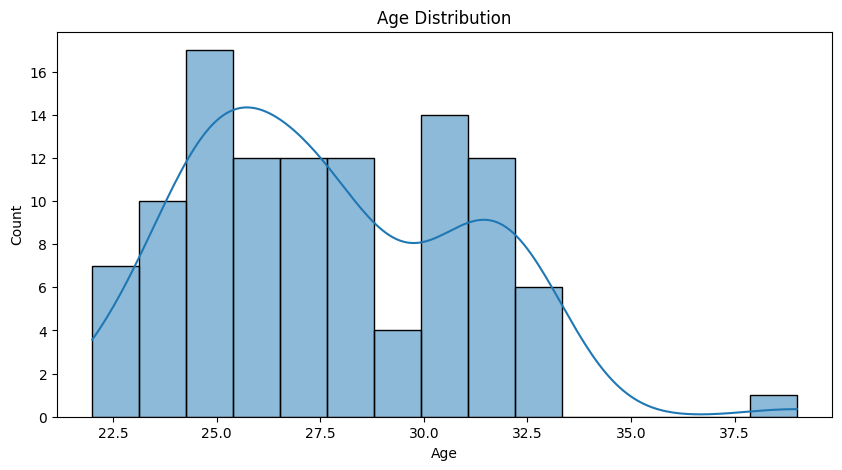

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(batter_pa50["Age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

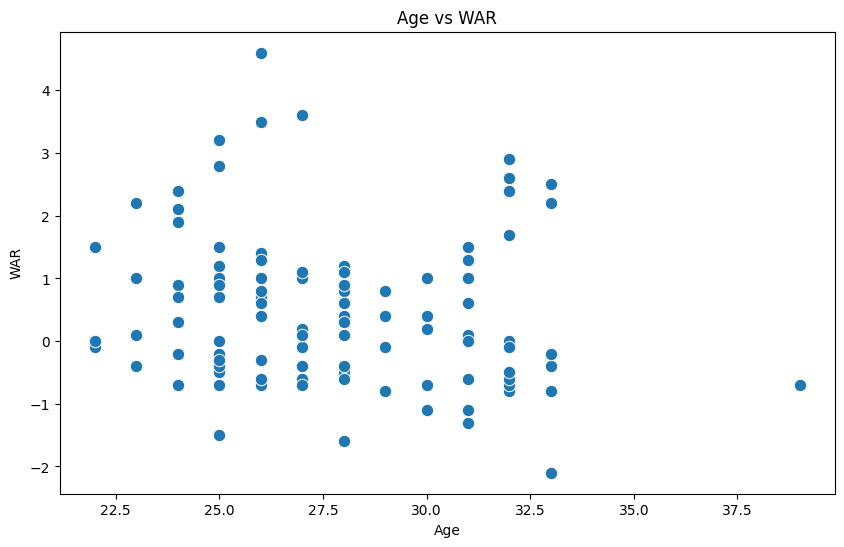

In [ ]:
# 나이 vs 성과
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="Age", y="WAR", s=80)

plt.title("Age vs WAR")
plt.xlabel("Age")
plt.ylabel("WAR")
plt.show()

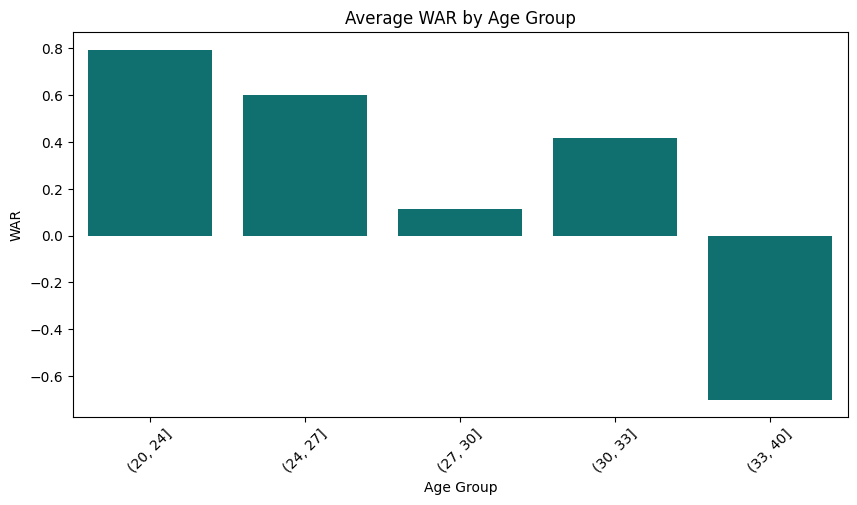

In [ ]:
# 나이 구간별 평균 WAR
batter_pa50["Age_bin"] = pd.cut(batter_pa50["Age"], bins=[20,24,27,30,33,40])

age_war = batter_pa50.groupby("Age_bin")["WAR"].mean()

plt.figure(figsize=(10,5))
sns.barplot(x=age_war.index.astype(str), y=age_war.values, color="teal")
plt.title("Average WAR by Age Group")
plt.xlabel("Age Group")
plt.ylabel("WAR")
plt.xticks(rotation=45)
plt.show()

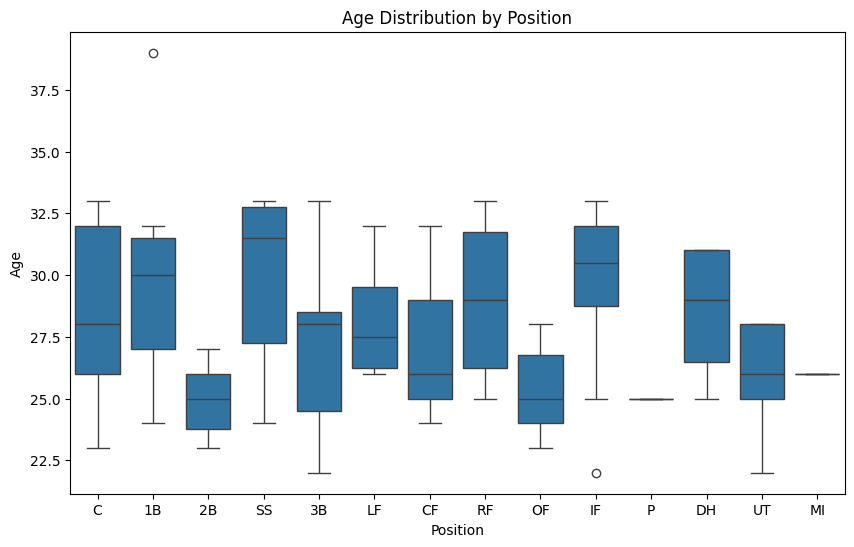

In [ ]:
# 포지션별 나이
plt.figure(figsize=(10,6))
sns.boxplot(data=batter_pa50, x="Pos", y="Age")

plt.title("Age Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Age")
plt.show()

In [ ]:
# 해석: C, 1B → 고령 많음. / CF → 젊은 선수 많음. 포지션별로 선수 나이 구조가 다르게 나타남.

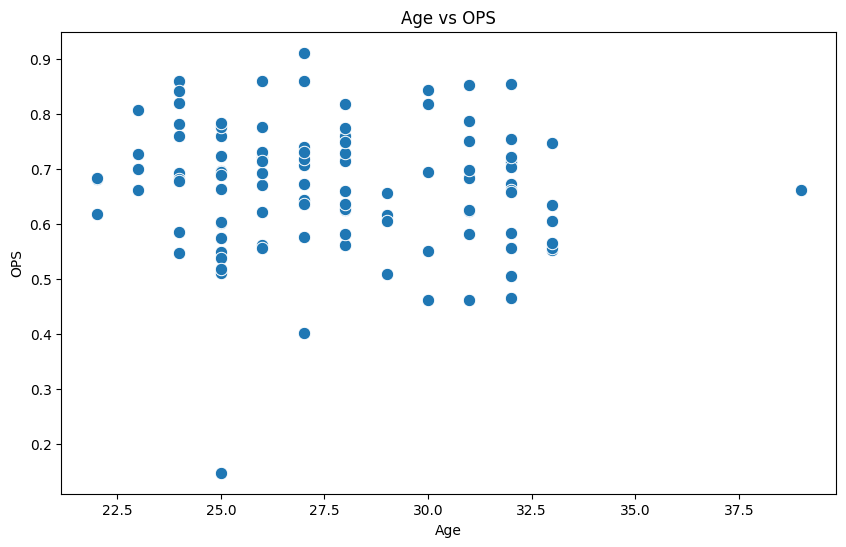

In [ ]:
# 나이 vs OPS (성과 비교)
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="Age", y="OPS", s=80)

plt.title("Age vs OPS")
plt.xlabel("Age")
plt.ylabel("OPS")
plt.show()

##### 해석: 일반적으로 20대 후반에서 성과가 가장 높음.

### G: 경기 수

In [ ]:
batter_pa50["G"].describe()

count    107.000000
mean      78.056075
std       38.481760
min       17.000000
25%       43.000000
50%       82.000000
75%      108.000000
max      153.000000
Name: G, dtype: float64

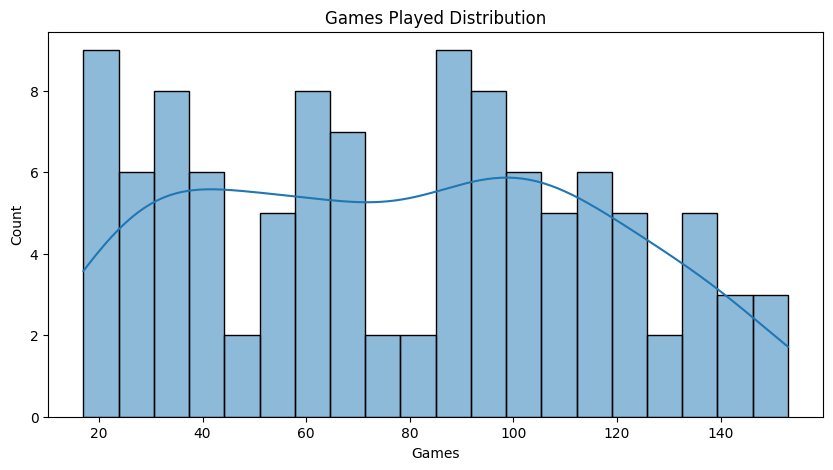

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(batter_pa50["G"], bins=20, kde=True)
plt.title("Games Played Distribution")
plt.xlabel("Games")
plt.ylabel("Count")
plt.show()

In [ ]:
# 주전 선수(G >= 120)
batter_pa50["is_fulltime"] = (batter_pa50["G"] >= 120).astype(int)

batter_pa50["is_fulltime"].value_counts()

is_fulltime
0    91
1    16
Name: count, dtype: int64

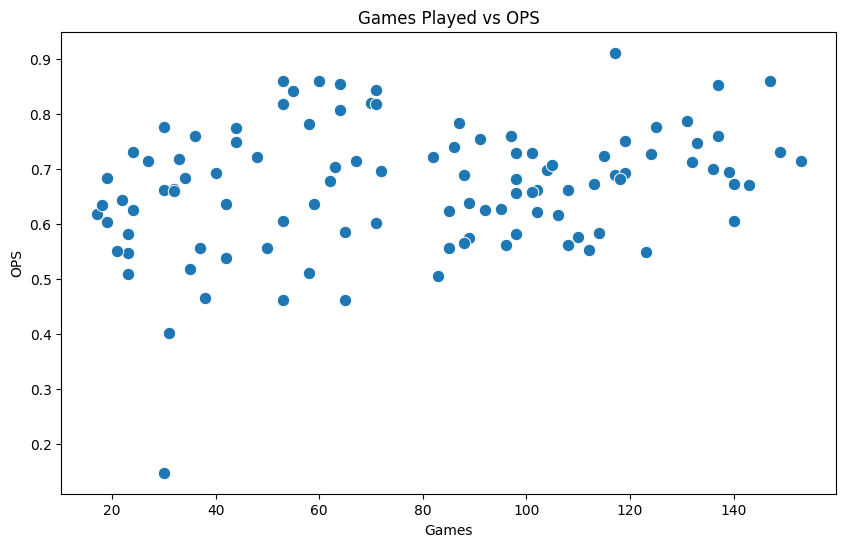

In [ ]:
# G vs OPS
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="G", y="OPS", s=80)

plt.title("Games Played vs OPS")
plt.xlabel("Games")
plt.ylabel("OPS")
plt.show()

##### G 높고 OPS 높으면 → 핵심 타자 / G 높고 OPS 낮으면 → 비효율 주전

In [ ]:
# 비효율 주전(OPS만 고려)
inefficient_players = batter_pa50[
    (batter_pa50["G"] >= 120) & 
    (batter_pa50["OPS"] < 0.700)
][["Player","year","G","OPS","WAR","PA","Pos"]].sort_values("OPS")

inefficient_players

,Player,year,G,OPS,WAR,PA,Pos
13,Magneuris Sierra*,2021,123.0,0.549,0.0,225,CF
54,Miguel Rojas,2022,140.0,0.605,2.5,507,SS
129,Otto LÃ³pez,2025,143.0,0.672,3.5,594,SS
127,Eric Wagaman,2025,140.0,0.674,-0.4,514,1B
128,Xavier Edwards#,2025,139.0,0.695,3.2,619,2B


In [ ]:
# 비효율 주전(OPS와 WAR 모두 고려)
inefficient_players = batter_pa50[
    (batter_pa50["G"] >= 120) & 
    (batter_pa50["OPS"] < 0.700) &
    (batter_pa50["WAR"] <= 0)
][["Player","year","G","OPS","WAR","PA","Pos"]]

inefficient_players

,Player,year,G,OPS,WAR,PA,Pos
13,Magneuris Sierra*,2021,123.0,0.549,0.0,225,CF
127,Eric Wagaman,2025,140.0,0.674,-0.4,514,1B


##### 총정리: 일부 선수는 많은 경기 수에도 불구하고 낮은 OPS와 WAR을 기록함. 이는 팀 내 비효율적인 자원 활용을 의미함.

### POS: 포지션

In [ ]:
batter_pa50["Pos"].value_counts()

Pos
C     13
1B    11
3B    11
CF    11
RF    10
OF    10
2B     8
IF     8
UT     7
SS     6
LF     6
DH     4
P      1
MI     1
Name: count, dtype: int64

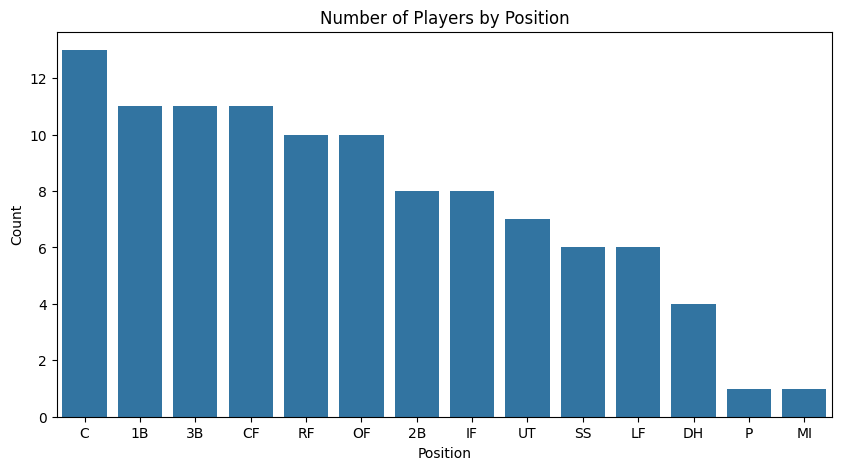

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=batter_pa50, x="Pos", order=batter_pa50["Pos"].value_counts().index)
plt.title("Number of Players by Position")
plt.xlabel("Position")
plt.ylabel("Count")
plt.show()

In [ ]:
# 포지션별 TOP 선수
top_pos = batter_pa50.sort_values(["Pos","WAR"], ascending=[True, False]).groupby("Pos").head(3)
top_pos[["Pos","Player","year","WAR","OPS"]]

,Pos,Player,year,WAR,OPS
1,1B,JesÃºs Aguilar,2021,1.3,0.788
17,1B,Lewin DÃ­az*,2021,0.9,0.693
107,1B,Jonah Bride,2024,0.9,0.818
78,2B,Luis ArrÃ¡ez*,2023,4.6,0.861
128,2B,Xavier Edwards#,2025,3.2,0.695
99,2B,Otto LÃ³pez,2024,2.8,0.690
4,3B,Brian Anderson,2021,1.2,0.715
90,3B,Jake Burger,2023,1.0,0.860
101,3B,Jake Burger,2024,0.8,0.760
63,C,Nick Fortes,2022,1.2,0.696


In [ ]:
# 포지션별 WORST 선수
bottom_pos = batter_pa50.sort_values(["Pos","WAR"], ascending=[True, True]) \
                      .groupby("Pos") \
                      .head(3)

bottom_pos[["Pos","Player","year","WAR","OPS"]]

,Pos,Player,year,WAR,OPS
52,1B,JesÃºs Aguilar,2022,-0.7,0.674
77,1B,Yuli Gurriel,2023,-0.7,0.663
141,1B,Matt Mervis*,2025,-0.7,0.637
93,2B,Xavier Edwards#,2023,0.1,0.663
112,2B,Luis ArrÃ¡ez*,2024,0.2,0.719
66,2B,Charles Leblanc,2022,0.7,0.723
80,3B,Jean Segura,2023,-2.1,0.556
109,3B,Emmanuel Rivera,2024,-0.6,0.563
70,3B,Jordan Groshans,2022,-0.1,0.619
14,C,Sandy LeÃ³n#,2021,-0.8,0.505


In [ ]:
# 포지션 단순화
def pos_group(p):
    if p in ["1B","2B","3B","SS"]:
        return "Infield"
    elif p in ["LF","CF","RF"]:
        return "Outfield"
    elif p == "C":
        return "Catcher"
    else:
        return "DH/Util"

batter_pa50["Pos_group"] = batter_pa50["Pos"].apply(pos_group)

In [ ]:
# 그룹별 평균 성과
pos_group_stats = batter_pa50.groupby("Pos_group")[["WAR", "OPS", "HR", "RBI", "SB"]].mean()
pos_group_stats

,WAR,OPS,HR,RBI,SB
Pos_group,,,,,
Catcher,-0.307692,0.566692,4.769231,21.769231,2.692308
DH/Util,0.425806,0.658000,5.967742,23.322581,4.387097
Infield,0.755556,0.692972,7.916667,32.500000,5.888889
Outfield,0.540741,0.696704,8.555556,31.333333,6.666667


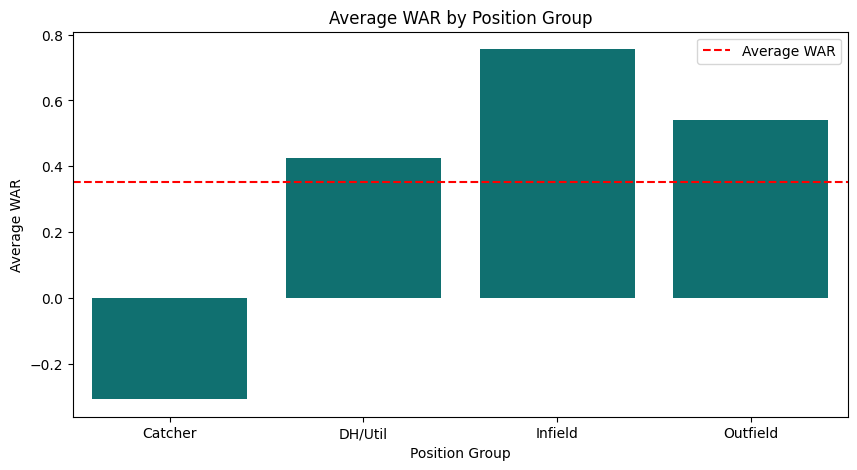

In [ ]:
# 그룹별 평균 WAR 시각화
plt.figure(figsize=(10,5))
sns.barplot(data=pos_group_stats.reset_index(), x="Pos_group", y="WAR", color="teal")
plt.axhline(pos_group_stats["WAR"].mean(), color="red", linestyle="--", label="Average WAR")
plt.title("Average WAR by Position Group")
plt.xlabel("Position Group")
plt.ylabel("Average WAR")
plt.legend()
plt.show()

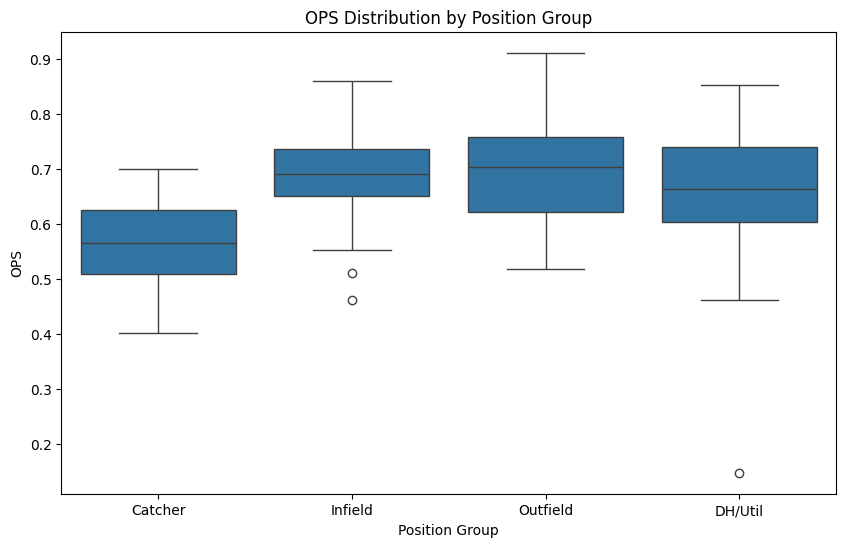

In [ ]:
# 그룹별 OPS 분포
plt.figure(figsize=(10,6))
sns.boxplot(data=batter_pa50, x="Pos_group", y="OPS")
plt.title("OPS Distribution by Position Group")
plt.xlabel("Position Group")
plt.ylabel("OPS")
plt.show()

##### 해석: Catcher 포지션 보강 필요.

### AB: 타수, H: 안타 수

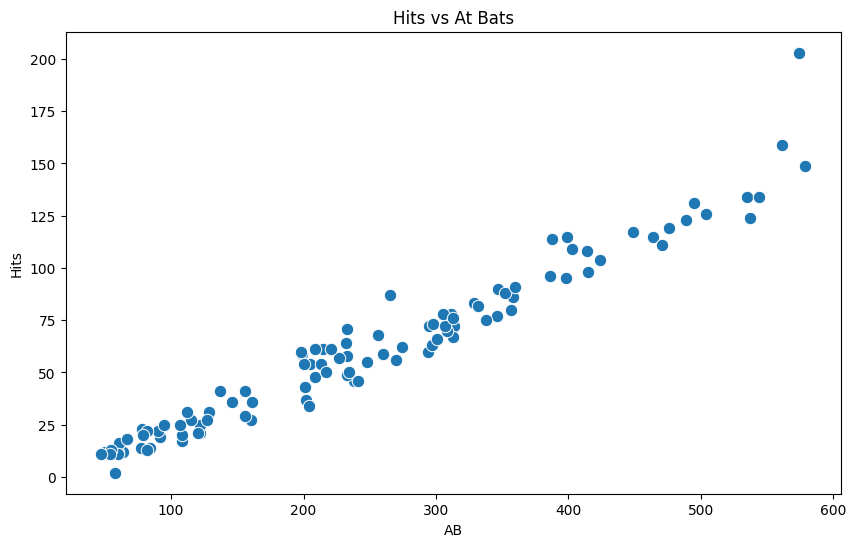

In [ ]:
# AB vs H 관계
plt.figure(figsize=(10,6))
sns.scatterplot(data=batter_pa50, x="AB", y="H", s=80)

plt.title("Hits vs At Bats")
plt.xlabel("AB")
plt.ylabel("Hits")
plt.show()

In [ ]:
# 해석: AB와 H는 강한 선형 관계. 동일한 AB에서도 선수별 H 차이가 존재하며 이는 타격 능력 차이를 의미함.

In [ ]:
# 고효율 타자(AB 대비 H 많은 선수)
high_contact = batter_pa50.sort_values("BA", ascending=False) \
                       [["Player","year","AB","H","BA","OPS"]]

high_contact.head(10)

,Player,year,AB,H,BA,OPS
78,Luis ArrÃ¡ez*,2023,574,203,0.354,0.861
100,Xavier Edwards#,2024,265,87,0.328,0.820
6,Starling Marte,2021,233,71,0.305,0.856
90,Jake Burger,2023,198,60,0.303,0.860
112,Luis ArrÃ¡ez*,2024,137,41,0.299,0.719
15,Bryan De La Cruz,2021,199,59,0.296,0.783
93,Xavier Edwards#,2023,78,23,0.295,0.663
85,Jon Berti,2023,388,114,0.294,0.748
137,Jakob Marsee*,2025,209,61,0.292,0.842
131,Kyle Stowers*,2025,399,115,0.288,0.912


In [ ]:
# 저효율 타자(AB 많지만 H 적은 선수) - 성과 낮음.
low_contact = batter_pa50[
    (batter_pa50["AB"] >= 300)
].sort_values("BA")[
    ["Player","year","AB","H","BA","OPS"]
]

low_contact.head(10)

,Player,year,AB,H,BA,OPS
57,JesÃºs SÃ¡nchez*,2022,313,67,0.214,0.682
80,Jean Segura,2023,301,66,0.219,0.556
55,Brian Anderson,2022,338,75,0.222,0.657
51,Jacob Stallings,2022,346,77,0.223,0.584
58,AvisaÃ­l GarcÃ­a,2022,357,80,0.224,0.582
97,Nick Fortes,2024,308,70,0.227,0.577
7,Adam Duvall,2021,314,72,0.229,0.755
126,AgustÃ­n RamÃ­rez,2025,537,124,0.231,0.701
132,Dane Myers,2025,307,72,0.235,0.617
54,Miguel Rojas,2022,471,111,0.236,0.605


### HR: 홈런 수, RBI: 타점

In [ ]:
batter_pa50[["HR","RBI"]].describe()

,HR,RBI
count,107.000000,107.000000
mean,7.130841,28.242991
std,6.774096,20.811753
min,0.000000,0.000000
25%,2.500000,11.500000
50%,5.000000,26.000000
75%,9.500000,39.000000
max,36.000000,93.000000


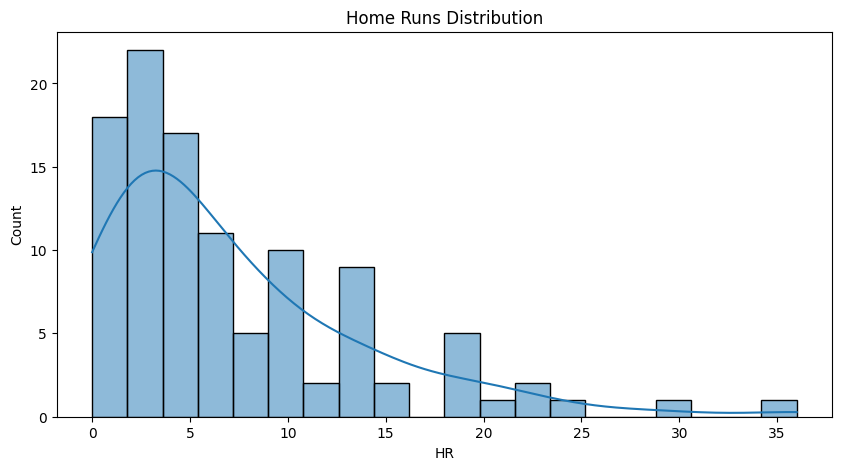

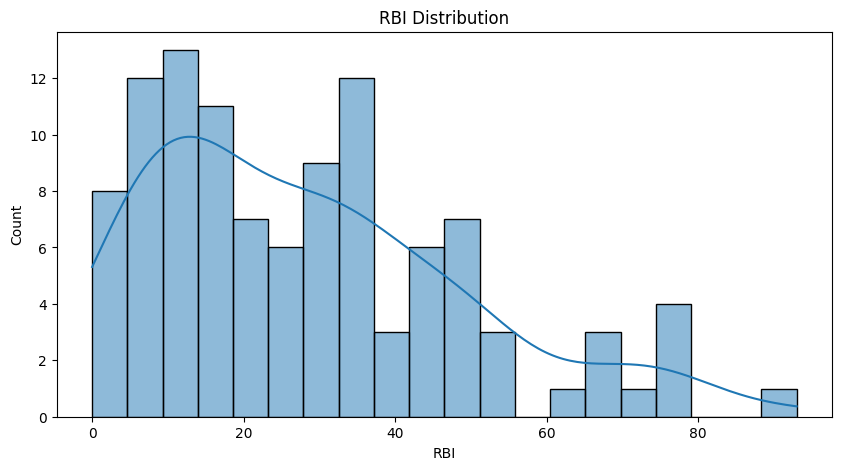

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(batter_pa50["HR"], bins=20, kde=True)
plt.title("Home Runs Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(batter_pa50["RBI"], bins=20, kde=True)
plt.title("RBI Distribution")
plt.show()

### SB: 도루 수, CS: 도루 실패 수

In [ ]:
batter_pa50[["SB","CS"]].describe()

,SB,CS
count,107.000000,107.000000
mean,5.261682,1.542056
std,7.518953,2.006030
min,0.000000,0.000000
25%,0.000000,0.000000
50%,2.000000,1.000000
75%,6.000000,2.000000
max,41.000000,8.000000


### BB: 볼넷 수, SO: 삼진 수

In [ ]:
batter_pa50[["BB","SO"]].describe()

,BB,SO
count,107.000000,107.000000
mean,20.186916,62.485981
std,13.522958,34.169766
min,1.000000,3.000000
25%,8.000000,37.500000
50%,19.000000,57.000000
75%,30.000000,85.500000
max,66.000000,150.000000


### 필요 없는 변수 삭제

In [ ]:
drop_cols = ["target", "undervalued_like", "Age_bin", "G_bin", "AB_bin", "is_fulltime"]

batter_pa50 = batter_pa50.drop(columns=drop_cols, errors="ignore")

In [ ]:
print(batter_pa50.columns.tolist())

['Player', 'Age', 'Pos', 'WAR', 'G', 'PA', 'AB', 'R', 'H', '2B', '3B', 'HR', 'RBI', 'SB', 'CS', 'BB', 'SO', 'BA', 'OBP', 'SLG', 'OPS', 'OPS+', 'rOBA', 'Rbat+', 'TB', 'GIDP', 'HBP', 'SH', 'SF', 'IBB', 'year', 'Pos_group']


In [ ]:
batter_pa50.to_csv("C:/Users/donge/OneDrive/바탕 화면/마린스 21-25 타자 데이터/타자 데이터.csv", index=False)